# Origin of replication

**Goal:**
Show the timing of origin firing. Compare to the cluster of genes that represent origin of replication complexes.

**Plan**
1. Show the chromatin timing for known origin of replication.
2. Show the timing for a stack of efficient origins of replication

**Notes**
- Origins centered on annotated/known ARS locations
    (stack up will be in aggregate)
- Origins are a mix of efficient and inefficient origins


In [10]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
import glob

chromatin_dir = 'output/deconvolve_origins_g0066_11x11_2024_09_10/chromatin/'
f_filepaths = glob.glob(f'{chromatin_dir}/*f*')


In [43]:
from src.global_config import GlobalConstants
from src.origins import load_origins_w_replication

# The origins will be loaded out of order, so let's use the
# origin dataset to assign the loaded f numpy array in the proper order
origins = load_origins_w_replication(full=False)
origins['origin_index'] = np.arange(len(origins))

n = len(f_filepaths)

deconvolved_origin_fs = None
origin_identifiers = []
for i in range(n):
    filepath = f_filepaths[i]
    
    # Retrieve the origin identifiers
    filename_split = filepath.split('/')[-1].split('_')
    ori, ars_name = filename_split[-2], filename_split[-1].split('.')[0]
    oridb_name = 'oridb_' + ori

    origin_f = np.load(filepath)
    if i == 0:
        deconvolved_origin_fs = np.zeros((n, *origin_f.shape))
    origin_index = origins.loc[oridb_name].origin_index

    deconvolved_origin_fs[origin_index] = origin_f

shape = deconvolved_origin_fs.shape
deconvolved_origin_f_images = deconvolved_origin_fs.reshape((shape[0], shape[1], 
    *GlobalConstants.ORC_IMAGE_SHAPE))


In [46]:
origins

,chr,pos,strand,footprint_class,nucleosome_shift_class,mcm_loading_class,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,acs_sequence,log2_acs_motif_score,ars_name,ars_start,ars_end,oridb_status,replication_time,replication_index,origin_index
name,,,,,,,,,,,,,,,,,
oridb_3,1,8221,-,g1_and_g2_footprint,downstream,downstream,late,-1.0000,GCTTTTTACTATTTGGGCCAGTATATCGGTATT,10.3753,ARS103,7997,8547,Confirmed,34.99247,123.0,0
oridb_7,1,42043,+,g1_and_g2_footprint,downstream,downstream,late,0.0319,AAAATTAACAATTAGGTTCATAGTCCCCTAATT,15.4399,ARS105,40715,43300,Confirmed,30.09272,114.0,1
oridb_8,1,70432,-,g1_and_g2_footprint,upstream,upstream,late,0.5054,ATTTTTTATGTTTAGAAACAAAATTTCCCCGAG,10.2180,ARS106,70256,70489,Confirmed,30.09272,114.0,2
oridb_10,1,124527,-,g1_and_g2_footprint,downstream,upstream,early,0.1319,ATTTTTTATATTTAAGTCTTGATTAACTGCTTT,19.1554,ARS107,124348,124597,Confirmed,28.45942,111.0,3
oridb_11,1,137561,+,g1_and_g2_footprint,static,downstream,early,-0.0233,CTTTTTTATTTTTGGTATTTCATTTATCCTATA,10.1736,ARS107.5,136898,137898,Confirmed,29.00387,112.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oridb_811,16,684410,+,g1_and_g2_footprint,upstream,upstream,early,0.5559,TTTTTTTACTTTTTGTTTCTTTATTAATTTTTT,17.2310,ARS1624,684388,684637,Confirmed,27.91497,110.0,234
oridb_813,16,695470,+,g1_and_g2_footprint,downstream,upstream,late,0.1725,AATTTTTATATTTGGTTCGAAAATTATGACATT,20.8511,ARS1625,695437,695686,Confirmed,28.45942,111.0,235
oridb_817,16,777099,-,g1_and_g2_footprint,upstream,downstream,early,0.7857,TTTATTTATATTTTGGCATTACTCTTCATCATT,18.2426,ARS1626.5,776925,777156,Confirmed,26.82617,108.0,236


In [ ]:
flipped_origins_f_images = deconvolved_origin_f_images.copy()
flipped_origins_f_images[upstream_loading_origins] = \
    np.flip(flipped_origins_f_images[upstream_loading_origins], axis=3)

In [75]:
late_efficient_origins_indices = origins[(origins.activation_time == 'late') & 
    (origins.derived_origin_efficiency_from_mcguffee_et_al_2013 > 0.5)].origin_index

early_efficient_origins_indices = origins[(origins.activation_time == 'early') & 
    (origins.derived_origin_efficiency_from_mcguffee_et_al_2013 > 0.5)].origin_index

In [72]:
upstream_loading_origins = origins[origins.mcm_loading_class == 'upstream'].origin_index

In [369]:
def plot_origins(origins_f, vmax=20):
    
    from src.figure_configs import FiguresConfig
    
    # Plot the origins at critical timepoints
    # Stack them up
    from src.config import load_configs_by_config_type
    config, _ = load_configs_by_config_type('shared')

    g1_indices = config.get_Hpositions_for_phase('CG1')
    s_indices = config.get_Hpositions_for_phase('S')
    g2m_indices = config.get_Hpositions_for_phase('G2M')

    phase_indices = [
        g1_indices[0], g1_indices[len(g1_indices)//3], g1_indices[len(g1_indices)*2//3], 
        s_indices[0], s_indices[len(s_indices)//3], s_indices[len(s_indices)*2//3], 
        g2m_indices[0], g2m_indices[len(g2m_indices)//3], g2m_indices[len(g2m_indices)*2//3], 
    ]

    combined_f_images = origins_f.mean(axis=0)

    def plot_origin_im(ax, f):
        
        #if should_smooth_data:
        from src.helpers import smooth_data
        smoothed_f = smooth_data(f, size=5, sigma=0.5)

        ax.imshow(smoothed_f, aspect='auto', origin='lower', 
            cmap='magma_r', vmax=vmax, extent=GlobalConstants.ORC_BIN_EXTENTS)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_xlim(-500, 500)
        ax.axvline(0, c='gray', alpha=0.125)
    
    fig, axs = plt.subplots(3, 3, figsize=(11, 4))
    axs = np.array(axs).T.flatten()

    for i in range(len(axs)):
        ax = axs[i]
        f_index = phase_indices[i]
        plot_origin_im(ax, combined_f_images[f_index])
        
        if i == 0: ax.set_title("Shared G1", fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)
        elif i == 3: ax.set_title("S",  fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)
        elif i == 6: ax.set_title("G2M",  fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)


In [421]:
from src.figure_configs import FiguresConfig

def plot_origin(origin):
    origin_index = origin.origin_index
    plot_origins(deconvolved_origin_f_images[origin_index:origin_index+1], vmax=20)
    plt.suptitle(f"{origin.ars_name}", 
        fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
    plt.subplots_adjust(top=0.82)

In [444]:
from src.peak_to_trough import compute_quantile_ptr_2d

# Find origins with the greatest cycling small fragments PTR
origin_small_fragments_occ = deconvolved_origin_f_images[:, t_indices, 0:10, :].mean(axis=2)
origin_small_fragments_occ_sum = origin_small_fragments_occ.sum(axis=2)

origin_small_ptrs = compute_quantile_ptr_2d(origin_small_fragments_occ_sum)
origin_ptrs = origins.copy()
origin_ptrs['small_ptr'] = origin_small_ptrs
sorted_origins_small_ptrs = origin_ptrs.sort_values('small_ptr', ascending=False)[['ars_name', 'activation_time', 'derived_origin_efficiency_from_mcguffee_et_al_2013', 'small_ptr']]
sorted_origins_small_ptrs.head(30)

,ars_name,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,small_ptr
name,,,,
oridb_625,ARS1330,early,0.6719,2.876861
oridb_418,ARS1004,late,0.1337,2.668594
oridb_498,ARS1120,late,0.7361,2.536307
oridb_628,ARS1331.7,late,0.0799,2.441841
oridb_551,NaN,late,-0.0091,2.325043
oridb_338,ARS804,late,0.1458,2.229711
oridb_73,ARS222,late,0.5435,2.194343
oridb_793,NaN,late,0.2830,2.089956
oridb_114,ARS318,late,0.0649,2.011473


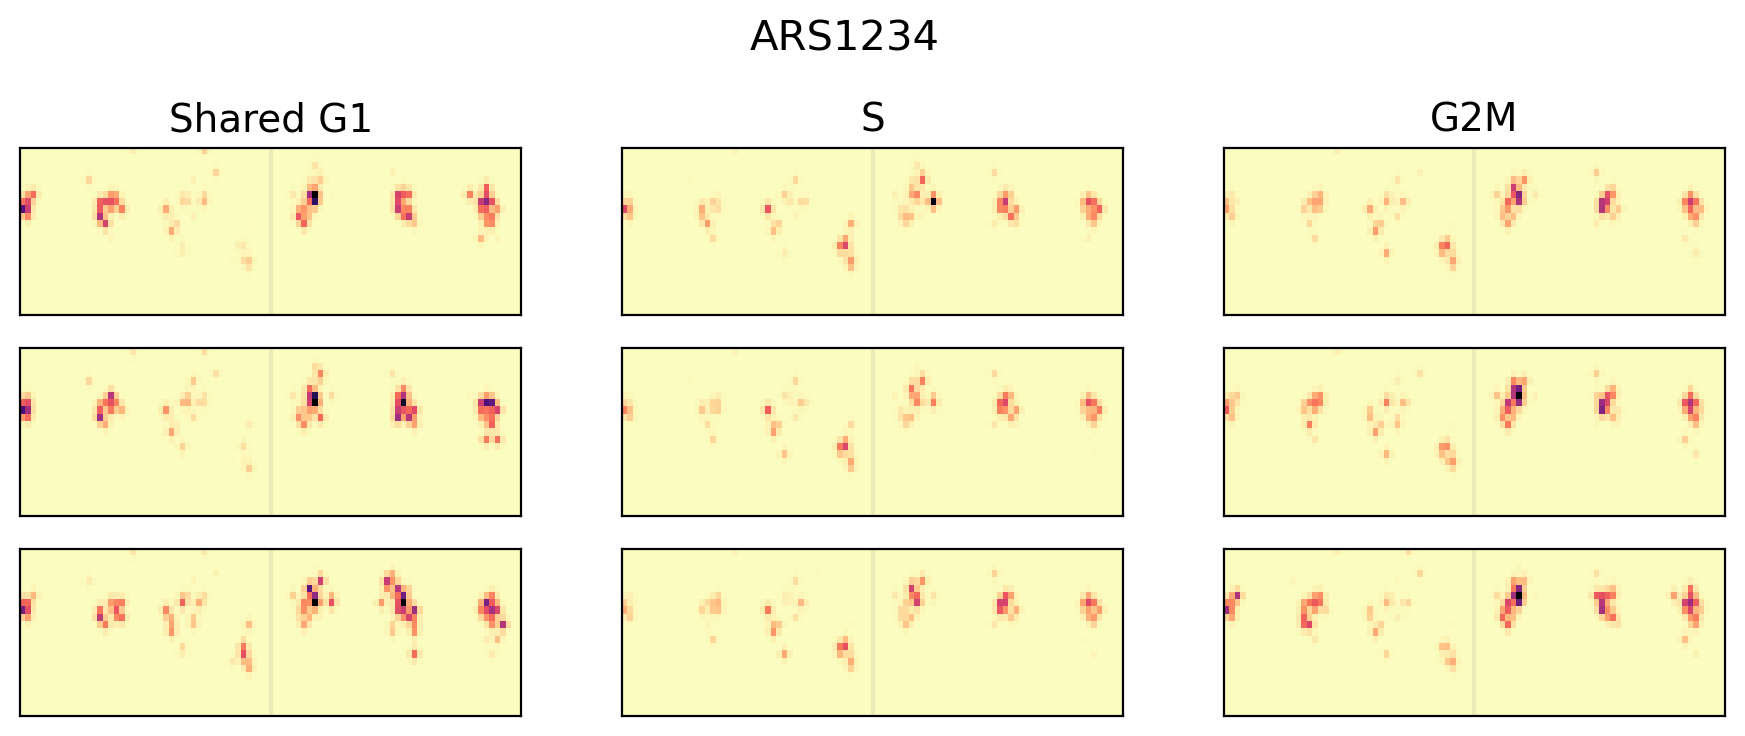

In [447]:
origin = origins.loc['oridb_567']
plot_origin(origin)

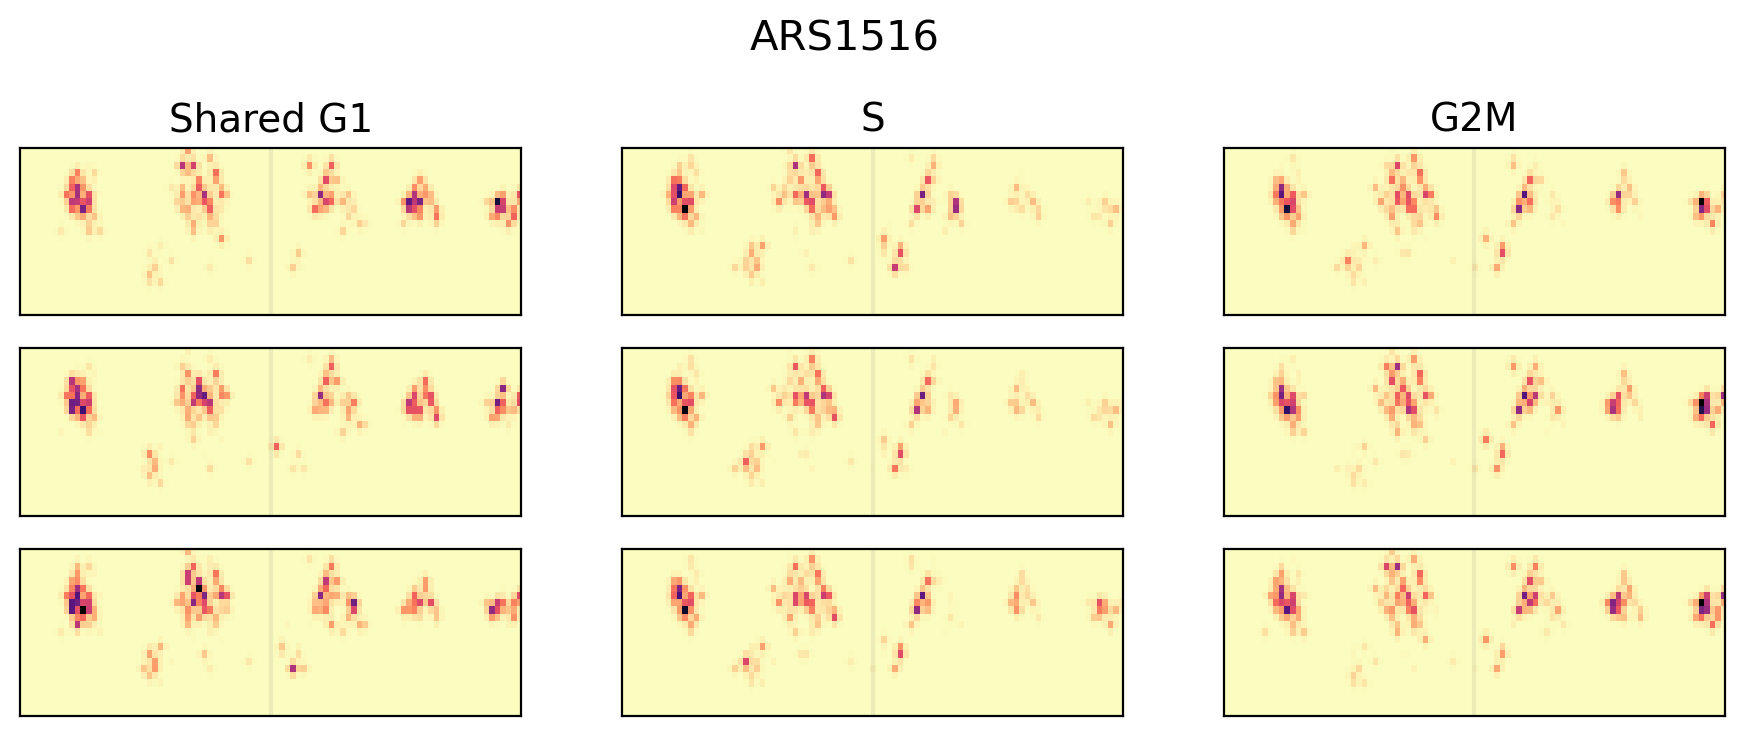

In [435]:
origin = origins.loc['oridb_721']
plot_origin(origin)

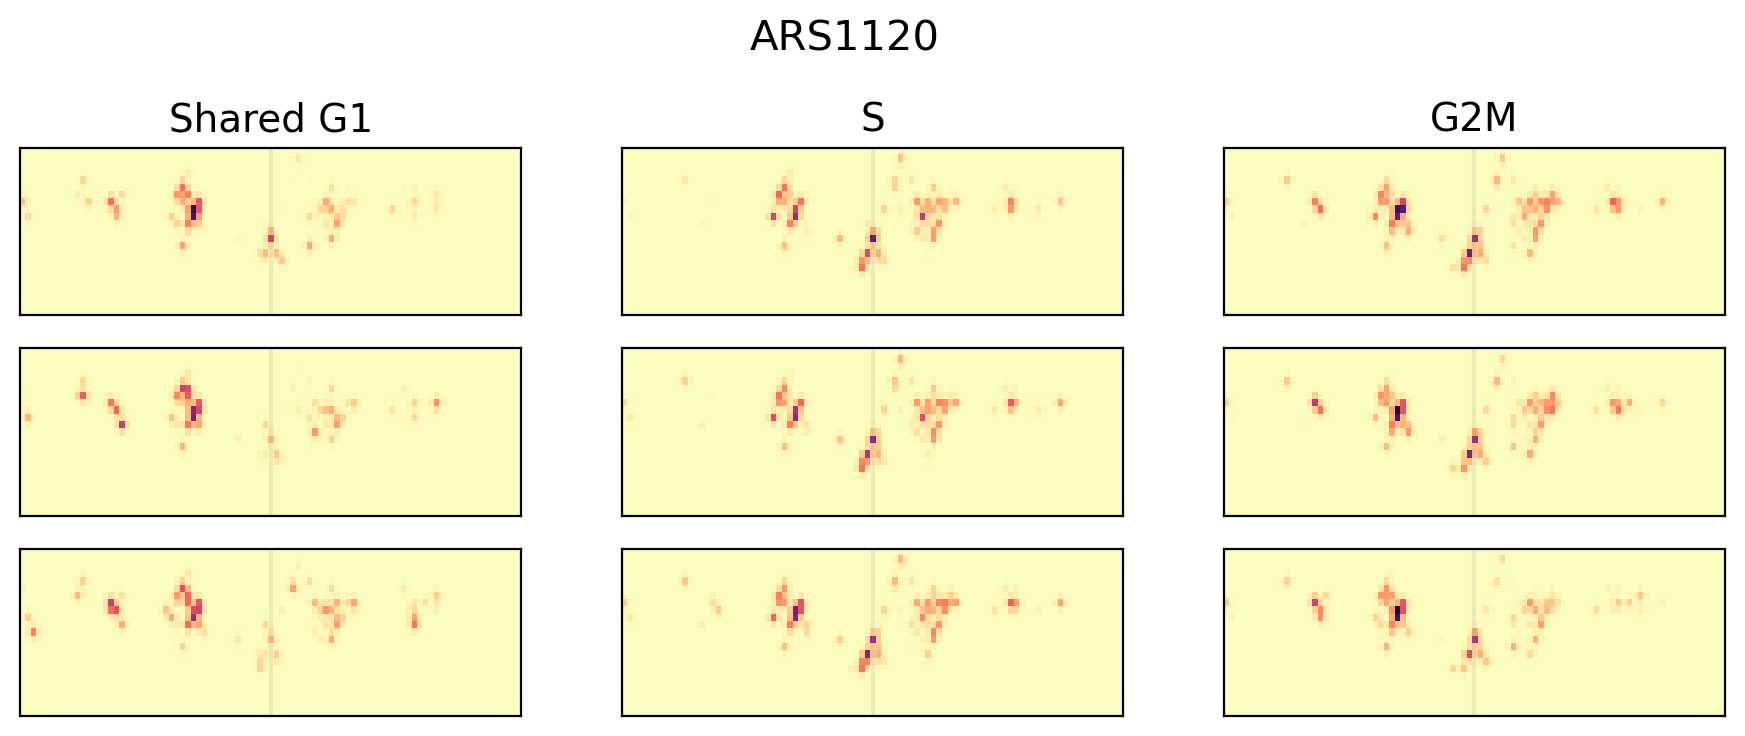

In [423]:
origin = origins.loc['oridb_498']
plot_origin(origin)